In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
IMBD_D = pd.read_csv(r"/content/IMDB Dataset.csv", engine='python', on_bad_lines='skip')
IMBD_D.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
IMBD_D.duplicated().sum()

np.int64(418)

In [6]:
IMBD_D.drop_duplicates(inplace=True)
IMBD_D.duplicated().sum()

np.int64(0)

In [7]:
IMBD_D.isnull().sum()

,0
review,0
sentiment,0


TEXT **PROCESSING**

In [8]:
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

negation_words = {'not', 'no', 'never', 'neither', 'nor', 'but', 'however', 'although'}
final_stop_words = [word for word in stop_words if word not in negation_words]
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:

def Tokenize(sentence):
    cleaned_sentence = re.sub(r"[^a-zA-Z0-9]", " ", sentence)
    return cleaned_sentence.lower().split()

Token = [Tokenize(sentence) for sentence in IMBD_D["review"]]

def Stop_rev_Word(tokens_list):
    return [word for word in tokens_list if word not in set(final_stop_words)]

Stop_Rev = [Stop_rev_Word(tokens) for tokens in Token]

def limm(W_):
    return [lemmatizer.lemmatize(word) for word in W_]

Lemmatize = [limm(W_) for W_ in Stop_Rev]

In [12]:
Sentences = [" ".join(words) for words in Lemmatize]

tf_idf = TfidfVectorizer(max_features=5000)
X_transformed = tf_idf.fit_transform(Sentences).toarray()

Target = IMBD_D["sentiment"].map({"positive": 1, "negative": 0})
train_X, test_X, train_Target, test_Target = train_test_split(X_transformed, Target, test_size=0.2, random_state=42)

X_tensor = torch.tensor(train_X, dtype=torch.float32)
Target_tensor = torch.tensor(train_Target.values, dtype=torch.float32).view(-1, 1)
test_X_tensor = torch.tensor(test_X, dtype=torch.float32)
test_Target_tensor = torch.tensor(test_Target.values, dtype=torch.float32).view(-1, 1)

Model = nn.Sequential(
    nn.Linear(5000, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

lf = nn.BCELoss()
Optimizer = optim.Adam(Model.parameters(), lr=0.001)

epochs = 100
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for ep in range(epochs):
    Model.train()
    Target_Pred = Model(X_tensor)
    loss = lf(Target_Pred, Target_tensor)

    Optimizer.zero_grad()
    loss.backward()
    Optimizer.step()

    train_acc = ((Target_Pred.round() == Target_tensor).float().mean()).item()

    Model.eval()
    with torch.no_grad():
        Test_Pred = Model(test_X_tensor)
        test_loss = lf(Test_Pred, test_Target_tensor)
        test_acc = ((Test_Pred.round() == test_Target_tensor).float().mean()).item()

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if (ep + 1) % 10 == 0:
        print(f"Epoch {ep + 1}/{epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 10/100, Train Loss: 0.4097, Test Loss: 0.6806, Train Acc: 0.8708, Test Acc: 0.8277
Epoch 20/100, Train Loss: 0.3470, Test Loss: 0.6592, Train Acc: 0.9092, Test Acc: 0.8707
Epoch 30/100, Train Loss: 0.3082, Test Loss: 0.6247, Train Acc: 0.9266, Test Acc: 0.8763
Epoch 40/100, Train Loss: 0.2783, Test Loss: 0.5742, Train Acc: 0.9380, Test Acc: 0.8757
Epoch 50/100, Train Loss: 0.2532, Test Loss: 0.5085, Train Acc: 0.9472, Test Acc: 0.8772
Epoch 60/100, Train Loss: 0.2323, Test Loss: 0.4332, Train Acc: 0.9546, Test Acc: 0.8764
Epoch 70/100, Train Loss: 0.2145, Test Loss: 0.3680, Train Acc: 0.9582, Test Acc: 0.8768
Epoch 80/100, Train Loss: 0.1995, Test Loss: 0.3293, Train Acc: 0.9631, Test Acc: 0.8767
Epoch 90/100, Train Loss: 0.1864, Test Loss: 0.3127, Train Acc: 0.9653, Test Acc: 0.8776
Epoch 100/100, Train Loss: 0.1763, Test Loss: 0.3071, Train Acc: 0.9674, Test Acc: 0.8757


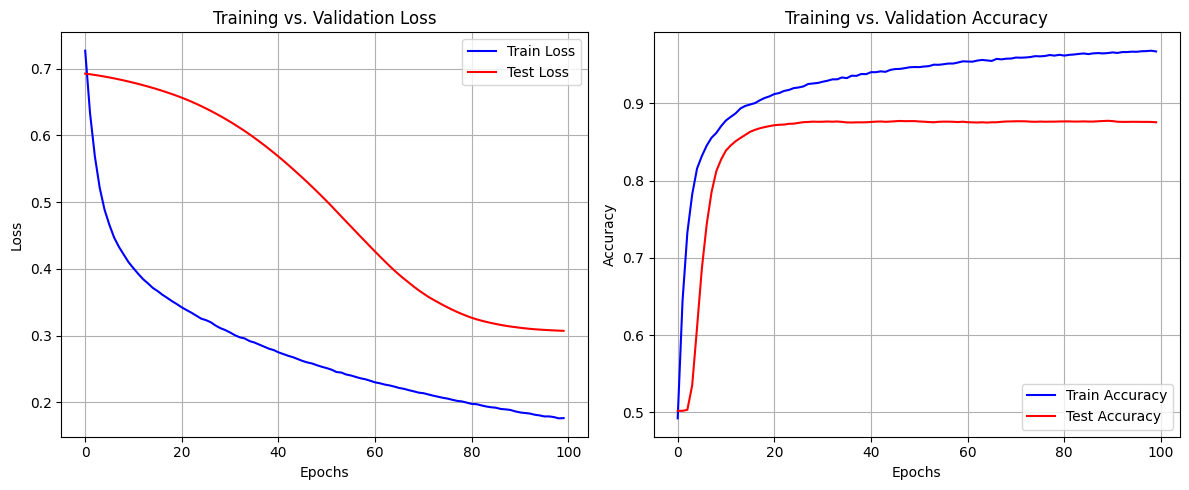

Final Test Accuracy: 0.8757
Final Test Loss: 0.3071


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.plot(test_accuracies, label='Test Accuracy', color='red')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


print(f"Final Test Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

**EXP** **2**

In [17]:
Model_2 = nn.Sequential(
    nn.Linear(5000, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

lf = nn.BCELoss()
Optimizer_2 = optim.Adam(Model_2.parameters(),lr=0.0007)

epochs = 100

train_losses_2, test_losses_2 = [], []
train_accuracies_2, test_accuracies_2 = [], []

for ep in range(epochs):
    Model_2.train()
    Optimizer_2.zero_grad()

    Target_Pred_2 = Model_2(X_tensor)
    loss_2 = lf(Target_Pred_2, Target_tensor)

    loss_2.backward()
    Optimizer_2.step()

    train_acc_2 = ((Target_Pred_2.round() == Target_tensor).float().mean()).item()

    Model_2.eval()
    with torch.no_grad():
        Test_Pred_2 = Model_2(test_X_tensor)
        test_loss_2 = lf(Test_Pred_2, test_Target_tensor)
        test_acc_2 = ((Test_Pred_2.round() == test_Target_tensor).float().mean()).item()

    train_losses_2.append(loss_2.item())
    test_losses_2.append(test_loss_2.item())
    train_accuracies_2.append(train_acc_2)
    test_accuracies_2.append(test_acc_2)

    if (ep + 1) % 10 == 0:
        print(f"Exp 2 - Epoch {ep + 1}/{epochs} | Train Loss: {loss_2.item():.4f} | Test Loss: {test_loss_2.item():.4f} | Test Acc: {test_acc_2:.4f}")

Exp 2 - Epoch 10/100 | Train Loss: 0.3775 | Test Loss: 0.6809 | Test Acc: 0.7213
Exp 2 - Epoch 20/100 | Train Loss: 0.2986 | Test Loss: 0.6588 | Test Acc: 0.8525
Exp 2 - Epoch 30/100 | Train Loss: 0.2555 | Test Loss: 0.6243 | Test Acc: 0.8674
Exp 2 - Epoch 40/100 | Train Loss: 0.2230 | Test Loss: 0.5737 | Test Acc: 0.8745
Exp 2 - Epoch 50/100 | Train Loss: 0.1977 | Test Loss: 0.5043 | Test Acc: 0.8762
Exp 2 - Epoch 60/100 | Train Loss: 0.1776 | Test Loss: 0.4249 | Test Acc: 0.8766
Exp 2 - Epoch 70/100 | Train Loss: 0.1600 | Test Loss: 0.3564 | Test Acc: 0.8775
Exp 2 - Epoch 80/100 | Train Loss: 0.1459 | Test Loss: 0.3170 | Test Acc: 0.8777
Exp 2 - Epoch 90/100 | Train Loss: 0.1336 | Test Loss: 0.3018 | Test Acc: 0.8761
Exp 2 - Epoch 100/100 | Train Loss: 0.1227 | Test Loss: 0.2979 | Test Acc: 0.8760


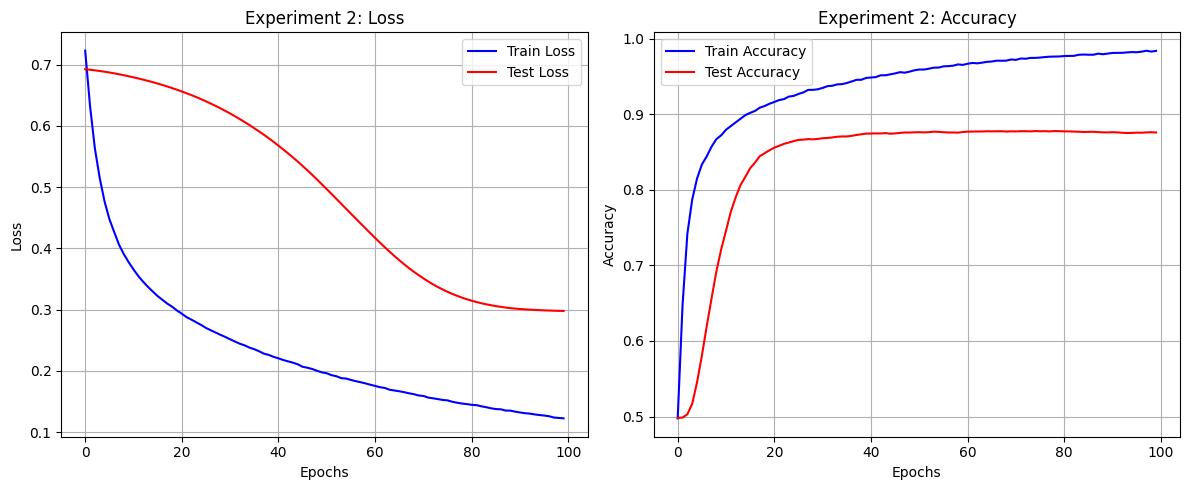

Exp 2 Final Test Accuracy: 0.8760
Exp 2 Final Test Loss: 0.2979


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_2, label='Train Loss', color='blue')
plt.plot(test_losses_2, label='Test Loss', color='red')
plt.title('Experiment 2: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_2, label='Train Accuracy', color='blue')
plt.plot(test_accuracies_2, label='Test Accuracy', color='red')
plt.title('Experiment 2: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Exp 2 Final Test Accuracy: {test_accuracies_2[-1]:.4f}")
print(f"Exp 2 Final Test Loss: {test_losses_2[-1]:.4f}")

In [19]:
import pickle
import torch

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tf_idf, f)

torch.save(Model_2.state_dict(), 'sentiment_model.pth')
print("Saved Experiment 2 model (64 neurons) successfully!")

Saved Experiment 2 model (64 neurons) successfully!


In [20]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import pickle
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

@st.cache_resource
def load_components():
    vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))

    model = nn.Sequential(
        nn.Linear(5000, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    model.load_state_dict(torch.load('sentiment_model.pth'))
    model.eval()
    return vectorizer, model

vectorizer, model = load_components()

stop_words_set = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    cleaned = re.sub(r"[^a-zA-Z0-9]", " ", text).lower().split()
    filtered = [word for word in cleaned if word not in stop_words_set]
    lemmatized = [lemmatizer.lemmatize(word) for word in filtered]
    return " ".join(lemmatized)

st.set_page_config(page_title="Movie Sentiment AI", page_icon="🎬")
st.title("🎬 Movie Review Sentiment Analyzer")
st.write("Predict whether a movie review is Positive or Negative using NN.")

user_input = st.text_area("Enter your review here:", height=150)

if st.button("Analyze Sentiment 🚀"):
    if user_input.strip() == "":
        st.warning("Please enter a review first!")
    else:
        cleaned_input = clean_text(user_input)
        vectorized_input = vectorizer.transform([cleaned_input]).toarray()
        tensor_input = torch.tensor(vectorized_input, dtype=torch.float32)

        with torch.no_grad():
            prediction = model(tensor_input).item()

        st.markdown("---")

        if prediction >= 0.50:
            st.success("### 🌟 Positive Review!")
            st.info(f"Model Confidence: {prediction:.2%}")
        else:
            st.error("### 😞 Negative Review!")
            st.info(f"Model Confidence: {(1 - prediction):.2%}")

Overwriting app.py


In [21]:
import urllib
password = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print("==================================================")
print(f"Endpoint IP (Password): {password}")
print("==================================================")

!streamlit run app.py & npx --yes localtunnel --port 8501

Endpoint IP (Password): 35.223.109.220
⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋2026-05-13 23:34:50.070 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.223.109.220:8501

your url is: https://nasty-hands-beam.loca.lt
  Stopping...
^C
